# 04 · Regression Analysis

**Project:** Hong Kong Cross-Border Passenger Traffic Analysis  
**Author:** Vila Chung · HKU BASc Social Data Science · 2025  
**CRISP-DM Phase:** Modelling → Evaluation  

---

## Objective

Build a **Multiple Linear Regression** model to predict daily total cross-border passenger volume.  
Unlike classification (Notebook 03) which predicts High/Low categories, regression predicts the **exact count**, enabling capacity planning and resource allocation.

| Item | Detail |
|------|--------|
| Input | `daily_traffic_processed.csv` (2023-01-08 to 2025-06-30) |
| DV (Target) | `Total` — daily aggregate passenger count |
| IVs (Features) | Month, DayOfWeek, Quarter, Is_Holiday, Is_Both_Holiday, Is_Weekend, Is_CNY, Is_GoldenWeek, Is_Easter, Year |
| Method | OLS Linear Regression with Z-score normalisation |
| Split | 80/20, random_state=42 |

---
## 0 · Environment Setup

In [1]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

RANDOM_STATE = 42
print('Environment ready.')

Environment ready.


---
## 1 · Load Data & Filter to Post-Reopening Period

In [2]:
# ── Load processed dataset ───────────────────────────────
df = pd.read_csv('daily_traffic_processed.csv', parse_dates=['Date'])

# ── Validate required columns (produced by Notebook 01) ──
required_cols = [
    'Is_HK_Holiday', 'Is_ML_Holiday', 'Is_Both_Holiday',
    'Is_Any_Holiday', 'Is_Holiday',
    'Is_Weekend', 'Is_CNY', 'Is_GoldenWeek', 'Is_Easter',
    'Year', 'Month', 'DayOfWeek', 'Quarter'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns — re-run Notebook 01 first: {missing}')

print(f'All {len(required_cols)} required columns verified.')

# ── Filter to 2023-2025 (post-reopening) ─────────────────
df = df[df['Date'] >= '2023-01-08'].copy()
print(f"Filtered dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nTotal (DV) statistics:")
print(df['Total'].describe().apply(lambda x: f"{x:,.0f}"))

All 13 required columns verified.
Filtered dataset: 1156 rows x 21 columns
Date range: 2023-01-08 to 2026-03-08

Total (DV) statistics:
count        1,156
mean       788,323
std        230,527
min         28,020
25%        646,686
50%        780,254
75%        946,099
max      1,342,500
Name: Total, dtype: str


---
## 2 · Feature & Target Definition

We use the same **10 independent variables** as the classification models for consistency.  
The key difference: the **dependent variable is continuous** (`Total` count) rather than binary.

In [3]:
# ── Define features and target ───────────────────────────
FEATURES = [
    'Month', 'DayOfWeek', 'Quarter', 'Is_Holiday', 'Is_Both_Holiday',
    'Is_Weekend', 'Is_CNY', 'Is_GoldenWeek', 'Is_Easter', 'Year'
]
TARGET = 'Total'

# Validate all feature columns exist
missing_cols = [c for c in FEATURES if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing feature columns: {missing_cols}')

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Target: {TARGET}")
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target range: {y.min():,.0f} – {y.max():,.0f}")
print(f"Target median: {y.median():,.0f}")
print(f"Target mean:   {y.mean():,.0f}")

Features (10): ['Month', 'DayOfWeek', 'Quarter', 'Is_Holiday', 'Is_Both_Holiday', 'Is_Weekend', 'Is_CNY', 'Is_GoldenWeek', 'Is_Easter', 'Year']
Target: Total

Feature matrix shape: (1156, 10)
Target range: 28,020 – 1,342,500
Target median: 780,254
Target mean:   788,323


---
## 3 · Train/Test Split & Z-Score Normalisation

Z-score standardisation (mean=0, std=1) is applied to the independent variables so that  
regression coefficients are **directly comparable** in magnitude — a larger |β| means stronger influence.

In [4]:
# ── 80/20 split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

# ── Z-score normalisation ────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nPost-scaling train mean: {X_train_scaled.mean(axis=0).round(2)}")
print(f"Post-scaling train std:  {X_train_scaled.std(axis=0).round(2)}")

Training set: 924 samples
Test set:     232 samples

Post-scaling train mean: [ 0.  0.  0.  0. -0. -0. -0. -0. -0.  0.]
Post-scaling train std:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 4 · Multiple Linear Regression — Model Training

In [5]:
# ── Train linear regression on standardised features ─────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# ── Predictions ──────────────────────────────────────────
y_pred_train = lr.predict(X_train_scaled)
y_pred_test = lr.predict(X_test_scaled)

print('Model trained successfully.')
print(f"Intercept (β₀): {lr.intercept_:,.2f}")

Model trained successfully.
Intercept (β₀): 788,950.61


---
## 5 · Model Evaluation

We evaluate using three standard regression metrics:
- **R²** — proportion of variance explained (1.0 = perfect)
- **RMSE** — root mean squared error (same unit as Total)
- **MAE** — mean absolute error (less sensitive to outliers)

In [6]:
# ── Compute metrics ──────────────────────────────────────
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

# ── Display results ──────────────────────────────────────
metrics_df = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE'],
    'Train': [f"{r2_train:.4f}", f"{rmse_train:,.0f}", f"{mae_train:,.0f}"],
    'Test': [f"{r2_test:.4f}", f"{rmse_test:,.0f}", f"{mae_test:,.0f}"]
})
print(metrics_df.to_string(index=False))

# ── Cross-validation ─────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])
cv_scores = cross_val_score(pipeline, X, y, cv=10, scoring='r2')
print(f"\n10-Fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold R²: {[f'{s:.4f}' for s in cv_scores]}")

Metric   Train    Test
    R²  0.7042  0.7423
  RMSE 126,839 111,145
   MAE  85,932  83,844

10-Fold CV R²: 0.3192 ± 0.5176
Per-fold R²: ['-1.1089', '0.5634', '0.5134', '-0.0347', '0.7065', '0.6646', '0.5456', '0.5075', '0.2729', '0.5618']


---
## 6 · Predicted vs Actual Scatter Plot

A well-fitting model should produce points clustered along the 45° diagonal.  
Deviations from the line indicate prediction errors — we will investigate these in the residual analysis.

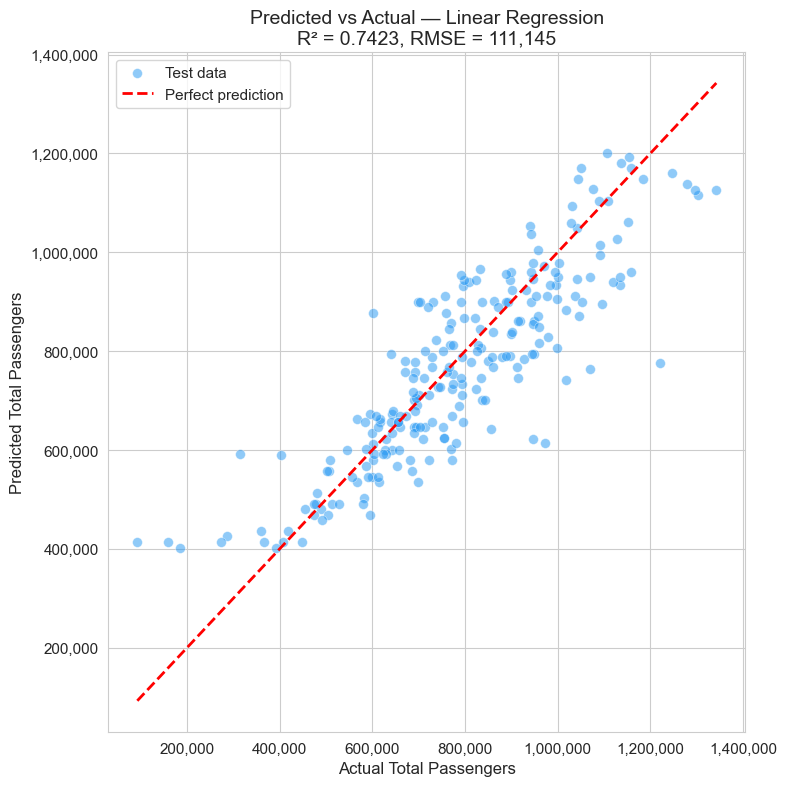

Figure saved: fig_04_01_predicted_vs_actual.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred_test, alpha=0.5, edgecolors='w',
           linewidth=0.5, s=50, color='#2196F3', label='Test data')

# Perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual Total Passengers')
ax.set_ylabel('Predicted Total Passengers')
ax.set_title(f'Predicted vs Actual — Linear Regression\nR² = {r2_test:.4f}, RMSE = {rmse_test:,.0f}')
ax.legend(loc='upper left')

# Format axis labels with comma separator
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('fig_04_01_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_04_01_predicted_vs_actual.png')

---
## 7 · Standardised Coefficient Plot

Since all IVs are Z-score normalised, the regression coefficients are **standardised (β)**  
and can be directly compared. A positive β means: as that feature increases by 1 SD, Total increases by β units.

### Reading guide

| Group | Features | What it captures |
|-------|----------|------------------|
| **Trend** | Year | Post-COVID recovery trajectory (2023 → 2025); not a controllable factor |
| **Cyclical** | Month, DayOfWeek, Quarter | Recurring weekly/seasonal patterns |
| **Holiday** | Is_Holiday, Is_Both_Holiday, Is_Weekend | General holiday/weekend effects |
| **Festival** | Is_CNY, Is_GoldenWeek, Is_Easter | Specific festival periods |

> **⚠️ Multicollinearity caveat:** Some festival features (e.g., `Is_CNY`, `Is_GoldenWeek`) may
> show **negative or unexpectedly small** coefficients. This does **not** mean these festivals
> reduce traffic — rather, it is a well-known artefact of **multicollinearity** in linear regression.
> When `Is_CNY = 1`, other correlated features (`Is_Holiday`, `Month`, `Year`) already capture
> much of the traffic surge, "squeezing" the remaining coefficient for `Is_CNY` into a negative
> residual value. The actual vs predicted comparison in Section 11 confirms that CNY traffic
> is in fact substantially **higher** than predicted.

Standardised Regression Coefficients:
  Is_GoldenWeek         -    13,432.82
  Is_Easter             +    18,616.96
  Is_Both_Holiday       +    19,905.48
  DayOfWeek             +    22,666.05
  Is_CNY                -    23,326.34
  Quarter               +    36,582.47
  Is_Holiday            +    37,873.08
  Month                 +    40,124.79
  Is_Weekend            +    87,662.15
  Year                  +   151,639.20


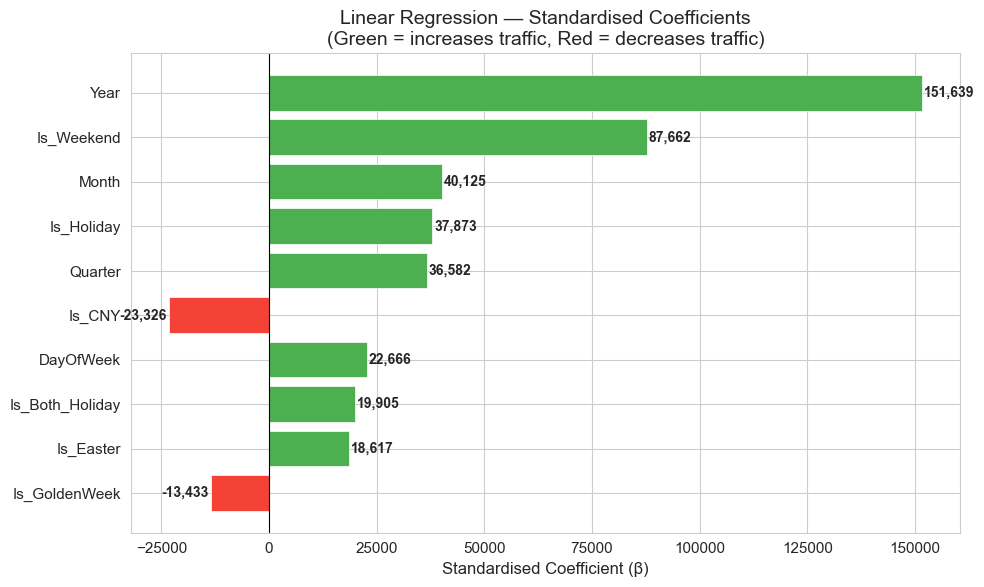

Figure saved: fig_04_02_coefficient_plot.png


In [8]:
# ── Coefficient table ────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

print("Standardised Regression Coefficients:")
print("=" * 45)
for _, row in coef_df.iterrows():
    direction = '+' if row['Coefficient'] > 0 else '-'
    print(f"  {row['Feature']:20s}  {direction} {abs(row['Coefficient']):>12,.2f}")

# ── Horizontal bar chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#4CAF50' if c > 0 else '#F44336' for c in coef_df['Coefficient']]

bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors,
               edgecolor='white', linewidth=0.5)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Standardised Coefficient (β)')
ax.set_title('Linear Regression — Standardised Coefficients\n(Green = increases traffic, Red = decreases traffic)')

# Add value labels
for bar, val in zip(bars, coef_df['Coefficient']):
    x_pos = val + (500 if val > 0 else -500)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', ha='left' if val > 0 else 'right',
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_04_02_coefficient_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_04_02_coefficient_plot.png')

---
## 8 · Residual Analysis

Residuals (Actual − Predicted) reveal where the model systematically fails.  
Good residuals should be:
- **Centred around zero** (no systematic bias)
- **Randomly scattered** (no patterns)
- **Normally distributed** (OLS assumption)

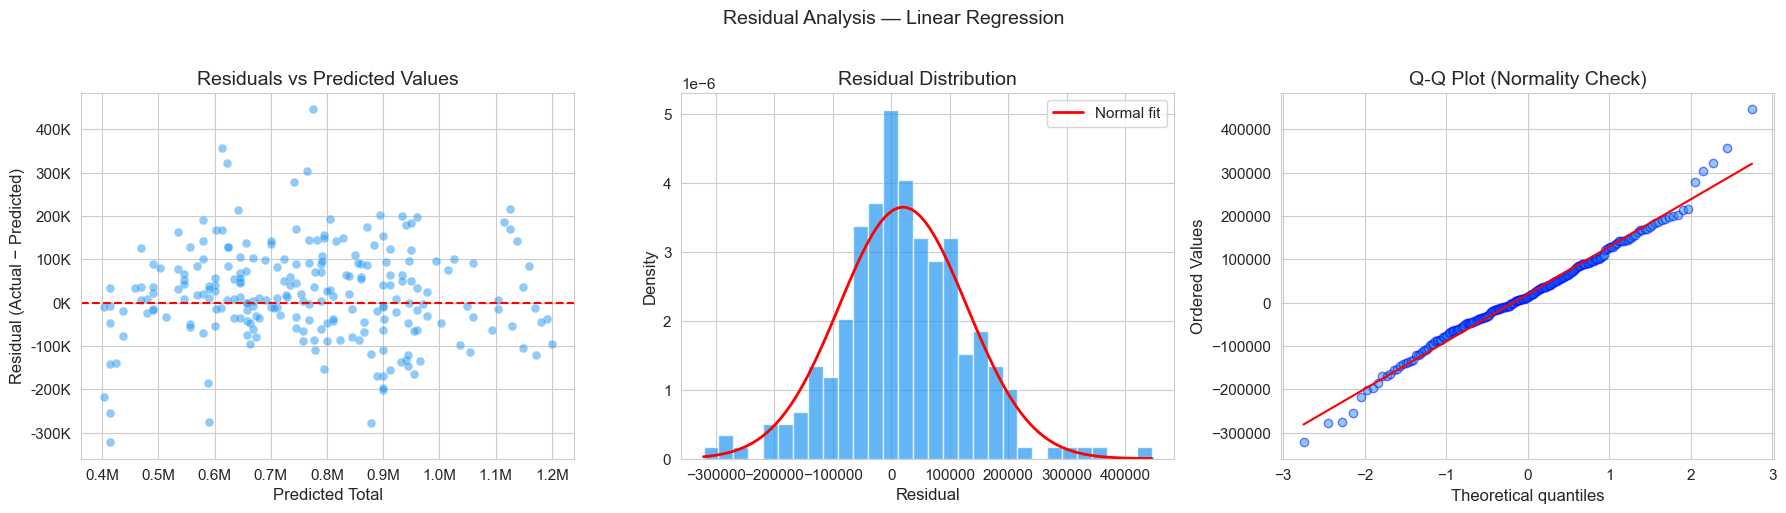

Figure saved: fig_04_03_residual_analysis.png


In [9]:
# ── Calculate residuals ──────────────────────────────────
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Residuals vs Predicted
axes[0].scatter(y_pred_test, residuals, alpha=0.5, s=40,
                edgecolors='w', linewidth=0.3, color='#2196F3')
axes[0].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Total')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Plot 2: Residual distribution
axes[1].hist(residuals, bins=30, color='#2196F3', edgecolor='white',
             alpha=0.7, density=True)
# Overlay normal curve
from scipy import stats
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
             'r-', linewidth=2, label='Normal fit')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Density')
axes[1].set_title('Residual Distribution')
axes[1].legend()

# Plot 3: Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')
axes[2].get_lines()[0].set_markerfacecolor('#2196F3')
axes[2].get_lines()[0].set_alpha(0.5)

plt.suptitle('Residual Analysis — Linear Regression', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_04_03_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_04_03_residual_analysis.png')

---
## 9 · Where Does the Model Fail? — Holiday Underprediction

Linear regression assumes **additive, linear effects**. During major festivals like CNY,  
the traffic surge is **multiplicative and non-linear** — the model cannot capture this.

In [10]:
# ── Build test result DataFrame for analysis ─────────────
test_results = df.loc[y_test.index].copy()
test_results['Predicted'] = y_pred_test
test_results['Residual'] = residuals
test_results['Abs_Residual'] = np.abs(residuals)
test_results['Pct_Error'] = (test_results['Residual'] / test_results['Total'] * 100)

# ── Top 10 worst predictions ─────────────────────────────
print("Top 10 Largest Prediction Errors:")
print("=" * 80)
worst = test_results.nlargest(10, 'Abs_Residual')[
    ['Date', 'Total', 'Predicted', 'Residual', 'Pct_Error',
     'Is_Holiday', 'Is_CNY', 'Is_GoldenWeek', 'Is_Easter', 'DayOfWeek']
].copy()
worst['Total'] = worst['Total'].apply(lambda x: f"{x:,.0f}")
worst['Predicted'] = worst['Predicted'].apply(lambda x: f"{x:,.0f}")
worst['Residual'] = worst['Residual'].apply(lambda x: f"{x:+,.0f}")
worst['Pct_Error'] = worst['Pct_Error'].apply(lambda x: f"{x:+.1f}%")
print(worst.to_string(index=False))

# ── Error by day type ────────────────────────────────────
print("\n\nMean Absolute Error by Day Type:")
print("=" * 50)

def classify_day(row):
    if row.get('Is_CNY', 0) == 1:
        return 'CNY'
    elif row.get('Is_GoldenWeek', 0) == 1:
        return 'Golden Week'
    elif row.get('Is_Easter', 0) == 1:
        return 'Easter'
    elif row.get('Is_Holiday', 0) == 1:
        return 'Other Holiday'
    elif row.get('Is_Weekend', 0) == 1:
        return 'Weekend'
    else:
        return 'Weekday'

test_results['Day_Type'] = test_results.apply(classify_day, axis=1)

error_by_type = test_results.groupby('Day_Type').agg(
    Count=('Abs_Residual', 'count'),
    Mean_Actual=('Total', 'mean'),
    MAE=('Abs_Residual', 'mean'),
    Mean_Pct_Error=('Pct_Error', lambda x: x.abs().mean())
).sort_values('MAE', ascending=False)

error_by_type['Mean_Actual'] = error_by_type['Mean_Actual'].apply(lambda x: f"{x:,.0f}")
error_by_type['MAE'] = error_by_type['MAE'].apply(lambda x: f"{x:,.0f}")
error_by_type['Mean_Pct_Error'] = error_by_type['Mean_Pct_Error'].apply(lambda x: f"{x:.1f}%")
print(error_by_type.to_string())

Top 10 Largest Prediction Errors:
      Date     Total Predicted Residual Pct_Error  Is_Holiday  Is_CNY  Is_GoldenWeek  Is_Easter  DayOfWeek
2025-01-31 1,221,954   775,811 +446,143    +36.5%           1       1              0          0          4
2024-03-28   971,676   613,423 +358,253    +36.9%           0       0              0          0          3
2023-12-26   946,136   622,917 +323,219    +34.2%           0       0              0          0          1
2023-01-11    92,345   413,555 -321,210   -347.8%           0       0              0          0          2
2025-01-30 1,068,786   764,543 +304,243    +28.5%           1       1              0          0          3
2023-12-25 1,018,637   740,669 +277,968    +27.3%           1       0              0          0          0
2025-08-05   600,515   877,515 -277,000    -46.1%           0       0              0          0          1
2023-09-08   314,601   590,726 -276,125    -87.8%           0       0              0          0          4
202

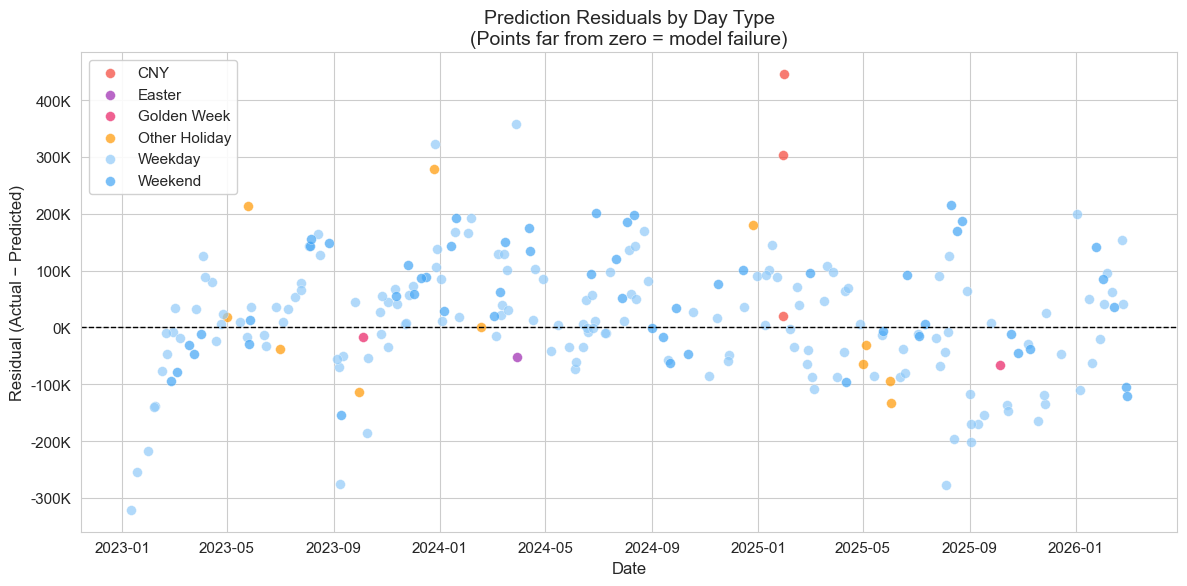

Figure saved: fig_04_04_residuals_by_type.png


In [11]:
# ── Visualise: Residuals coloured by day type ────────────
fig, ax = plt.subplots(figsize=(12, 6))

type_colors = {
    'Weekday': '#90CAF9',
    'Weekend': '#42A5F5',
    'Other Holiday': '#FF9800',
    'CNY': '#F44336',
    'Golden Week': '#E91E63',
    'Easter': '#9C27B0'
}

for day_type, group in test_results.groupby('Day_Type'):
    ax.scatter(group['Date'], group['Residual'],
              label=day_type, color=type_colors.get(day_type, 'grey'),
              alpha=0.7, s=50, edgecolors='w', linewidth=0.3)

ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Prediction Residuals by Day Type\n(Points far from zero = model failure)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig('fig_04_04_residuals_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_04_04_residuals_by_type.png')

---
## 10 · Correlation vs Causation (L6 Concept)

### Important Distinction

Our regression model identifies **statistical associations**, not **causal relationships**.

| What the model shows | What it does NOT prove |
|---------------------|------------------------|
| `Is_Weekend` correlates with higher traffic | Weekends *cause* people to travel |
| `Is_CNY` correlates with traffic spikes | CNY alone drives the increase |
| `Year` shows upward trend | Recovery is guaranteed to continue |

### Why this matters:

1. **Confounding variables**: Weekend traffic may be high because of leisure travel patterns,  
   shopping behaviour, or Mainland visitor schedules — not the day itself.

2. **Reverse causality**: The model treats holidays as *predictors* of traffic, but in reality,  
   the government schedules immigration resources *because of* expected traffic — a feedback loop.

3. **Omitted variable bias**: Factors not in our model (weather, exchange rates, visa policies,  
   Mainland economic conditions) may be the true drivers.

4. **Ecological fallacy**: We model aggregate daily totals across all 17 control points.  
   Patterns at individual checkpoints (e.g., Lo Wu vs Airport) may differ substantially.

**Conclusion**: The R² value (reported in Section 5) tells us how much variance temporal and holiday
features explain. The remainder is driven by unobserved factors that a simple linear model cannot capture.  
Policy recommendations should be treated as **hypotheses to test**, not proven causal claims.

---
## 11 · Holiday Significance Analysis

Which holiday features are the most significant predictors of passenger traffic?

In [12]:
# ── Holiday feature coefficient analysis ─────────────────
holiday_features = ['Is_Holiday', 'Is_Both_Holiday', 'Is_CNY', 'Is_GoldenWeek', 'Is_Easter', 'Is_Weekend']
holiday_coefs = coef_df[coef_df['Feature'].isin(holiday_features)].copy()
holiday_coefs = holiday_coefs.sort_values('Coefficient', ascending=False)

print("Holiday Feature Coefficients (Standardised):")
print("=" * 55)
for _, row in holiday_coefs.iterrows():
    effect = 'INCREASES' if row['Coefficient'] > 0 else 'DECREASES'
    print(f"  {row['Feature']:20s} β = {row['Coefficient']:>+12,.2f}  → {effect} traffic")

# ── Actual vs predicted for holiday periods ──────────────
print("\n\nActual vs Predicted Average by Holiday Type:")
print("=" * 65)

for htype in ['Is_CNY', 'Is_GoldenWeek', 'Is_Easter', 'Is_Both_Holiday']:
    if htype in test_results.columns:
        mask = test_results[htype] == 1
        if mask.sum() > 0:
            actual_avg = test_results.loc[mask, 'Total'].mean()
            pred_avg = test_results.loc[mask, 'Predicted'].mean()
            gap = actual_avg - pred_avg
            print(f"  {htype:18s}  n={mask.sum():3d}  "
                  f"Actual={actual_avg:>10,.0f}  "
                  f"Predicted={pred_avg:>10,.0f}  "
                  f"Gap={gap:>+10,.0f}")

Holiday Feature Coefficients (Standardised):
  Is_Weekend           β =   +87,662.15  → INCREASES traffic
  Is_Holiday           β =   +37,873.08  → INCREASES traffic
  Is_Both_Holiday      β =   +19,905.48  → INCREASES traffic
  Is_Easter            β =   +18,616.96  → INCREASES traffic
  Is_GoldenWeek        β =   -13,432.82  → DECREASES traffic
  Is_CNY               β =   -23,326.34  → DECREASES traffic


Actual vs Predicted Average by Holiday Type:
  Is_CNY              n=  3  Actual= 1,021,361  Predicted=   764,543  Gap=  +256,818
  Is_GoldenWeek       n=  2  Actual=   764,878  Predicted=   806,234  Gap=   -41,355
  Is_Easter           n=  1  Actual= 1,076,058  Predicted= 1,128,974  Gap=   -52,916
  Is_Both_Holiday     n=  7  Actual=   972,537  Predicted=   889,850  Gap=   +82,686


### Interpretation: Why the Model Underpredicts Festivals

The residual analysis reveals a systematic pattern: **the model consistently underpredicts  
traffic during major festivals**, particularly CNY.

**Root cause — Linearity assumption**:

Linear regression models effects as **additive**: `Total = β₀ + β₁·Is_CNY + β₂·Is_Weekend + ...`

But festival traffic is **non-linear and interactive**:
- CNY 2024 (Feb 10–13): Traffic surged to >1.2 million/day — far above what a single binary flag can capture.
- The *duration* of holiday periods (multi-day vs single-day) matters, but binary flags lose this information.
- **Interaction effects** (e.g., CNY + Weekend creates a super-peak) are not modelled.

**Potential improvements** (beyond this course's scope):
- Add interaction terms (e.g., `Is_CNY × Is_Weekend`)
- Use polynomial features or splines
- Use tree-based models (Random Forest, XGBoost) that naturally capture non-linearity

---
## 12 · Summary

| Aspect | Finding |
|--------|--------|
| **R²** | See Section 5 output — temporal + holiday features explain the majority of daily traffic variance |
| **RMSE** | See Section 5 output — average prediction error in passenger count |
| **Strongest predictor** | `Is_Weekend` and `Year` — structural weekend patterns and post-COVID recovery trend |
| **Festival significance** | CNY and Easter show the largest actual traffic surges; negative coefficients for some festivals are due to multicollinearity (see Section 7 caveat) |
| **Key limitation** | Linear model cannot capture non-linear festival surges or interaction effects |
| **Causation caveat** | Correlation ≠ Causation — unobserved confounders (weather, policy, economy) may be true drivers |

### Next Steps

→ **Notebook 05**: K-Means Clustering to discover natural traffic patterns,  
  and Association Rule Mining to identify co-occurring conditions for extreme traffic days.